In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/bdc3013/featureengineering-clean/train_clean.csv")

print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['TARGET'].value_counts()}")
print(f"Positive rate: {df['TARGET'].mean():.3%}")

Shape: (76020, 97)
Target distribution:
TARGET
0    73012
1     3008
Name: count, dtype: int64
Positive rate: 3.957%


In [4]:
drop_cols = ["ID", "TARGET"]

X = df.drop(columns=drop_cols)
y = df["TARGET"]

print(f"Features: {X.shape[1]}")  # will print 95
print(f"Samples : {X.shape[0]}")

Features: 95
Samples : 76020


In [5]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

metrics = {"fold": [], "auc": [], "accuracy": [],
           "precision": [], "recall": [], "f1": []}

oof_preds  = np.zeros(len(y))
oof_labels = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr,  y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Scale: fit on train only — no data leakage
    scaler    = StandardScaler()
    X_tr_sc   = scaler.fit_transform(X_tr)
    X_val_sc  = scaler.transform(X_val)

    # class_weight="balanced" handles the heavy 96/4 imbalance
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
        C=0.1,
        random_state=42
    )
    model.fit(X_tr_sc, y_tr)

    y_prob = model.predict_proba(X_val_sc)[:, 1]
    y_pred = model.predict(X_val_sc)

    oof_preds[val_idx]  = y_prob
    oof_labels[val_idx] = y_val

    auc  = roc_auc_score(y_val, y_prob)
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)

    for k, v in zip(["fold","auc","accuracy","precision","recall","f1"],
                      [fold, auc, acc, prec, rec, f1]):
        metrics[k].append(v)

    print(f"Fold {fold} | AUC={auc:.4f}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")

Fold 1 | AUC=0.7953  Acc=0.7438  Prec=0.1006  Rec=0.6905  F1=0.1756
Fold 2 | AUC=0.8132  Acc=0.7420  Prec=0.1070  Rec=0.7521  F1=0.1873
Fold 3 | AUC=0.8146  Acc=0.7489  Prec=0.1084  Rec=0.7392  F1=0.1890
Fold 4 | AUC=0.7967  Acc=0.7400  Prec=0.1044  Rec=0.7342  F1=0.1828
Fold 5 | AUC=0.7988  Acc=0.7482  Prec=0.1042  Rec=0.7060  F1=0.1817


In [6]:
results = pd.DataFrame(metrics)
display(results.style.format({
    "auc":"{:.4f}", "accuracy":"{:.4f}",
    "precision":"{:.4f}", "recall":"{:.4f}", "f1":"{:.4f}"
}))

,fold,auc,accuracy,precision,recall,f1
0,1,0.7953,0.7438,0.1006,0.6905,0.1756
1,2,0.8132,0.7420,0.1070,0.7521,0.1873
2,3,0.8146,0.7489,0.1084,0.7392,0.1890
3,4,0.7967,0.7400,0.1044,0.7342,0.1828
4,5,0.7988,0.7482,0.1042,0.7060,0.1817


In [7]:
print("="*55)
print("Cross-Validation Summary (mean ± std)")
print("="*55)
for col in ["auc", "accuracy", "precision", "recall", "f1"]:
    m, s = results[col].mean(), results[col].std()
    print(f"  {col.capitalize():<12}: {m:.4f} ± {s:.4f}")

oof_auc = roc_auc_score(oof_labels, oof_preds)
print(f"\n  OOF AUC (global): {oof_auc:.4f}")

Cross-Validation Summary (mean ± std)
  Auc         : 0.8037 ± 0.0094
  Accuracy    : 0.7446 ± 0.0039
  Precision   : 0.1049 ± 0.0030
  Recall      : 0.7244 ± 0.0253
  F1          : 0.1833 ± 0.0053

  OOF AUC (global): 0.8036


In [8]:
oof_binary = (oof_preds >= 0.5).astype(int)
cm = confusion_matrix(oof_labels, oof_binary)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
print("OOF Confusion Matrix:")
display(cm_df)

OOF Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,54423,18589
Actual 1,829,2179


In [9]:
# Search over C — the only free parameter in logistic regression
C_grid = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

c_results = []

for C in C_grid:
    fold_aucs = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in skf.split(X, y):
        X_tr,  X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr,  y_val = y.iloc[train_idx], y.iloc[val_idx]

        scaler   = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_tr)
        X_val_sc = scaler.transform(X_val)

        model = LogisticRegression(
            C=C, max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42
        )
        model.fit(X_tr_sc, y_tr)
        y_prob = model.predict_proba(X_val_sc)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, y_prob))

    mean_auc = np.mean(fold_aucs)
    std_auc  = np.std(fold_aucs)
    c_results.append({"C": C, "mean_auc": mean_auc, "std_auc": std_auc})
    print(f"C={C:<6} | AUC={mean_auc:.4f} ± {std_auc:.4f}")

c_df = pd.DataFrame(c_results)
best_C = c_df.loc[c_df["mean_auc"].idxmax(), "C"]
print(f"\nBest C: {best_C}")

C=0.001  | AUC=0.8039 ± 0.0087
C=0.01   | AUC=0.8044 ± 0.0089
C=0.05   | AUC=0.8038 ± 0.0084
C=0.1    | AUC=0.8037 ± 0.0084
C=0.5    | AUC=0.8036 ± 0.0085
C=1.0    | AUC=0.8035 ± 0.0084
C=5.0    | AUC=0.8035 ± 0.0084
C=10.0   | AUC=0.8035 ± 0.0085

Best C: 0.01


In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_tuned  = np.zeros(len(y))
oof_labels_tuned = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr,  y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)

    model = LogisticRegression(
        C=best_C, max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    )
    model.fit(X_tr_sc, y_tr)

    oof_preds_tuned[val_idx]  = model.predict_proba(X_val_sc)[:, 1]
    oof_labels_tuned[val_idx] = y_val
    print(f"Fold {fold} done")

print(f"\nOOF AUC (best C={best_C}): {roc_auc_score(oof_labels_tuned, oof_preds_tuned):.4f}")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

OOF AUC (best C=0.01): 0.8042


In [11]:
# Sweep thresholds on OOF probs — no leakage since these are held-out predictions
thresholds = np.arange(0.05, 0.70, 0.01)
thresh_results = []

for t in thresholds:
    preds = (oof_preds_tuned >= t).astype(int)
    thresh_results.append({
        "threshold": round(t, 2),
        "precision": precision_score(oof_labels_tuned, preds, zero_division=0),
        "recall":    recall_score(oof_labels_tuned, preds, zero_division=0),
        "f1":        f1_score(oof_labels_tuned, preds, zero_division=0),
    })

thresh_df  = pd.DataFrame(thresh_results)
best_row   = thresh_df.loc[thresh_df["f1"].idxmax()]
best_thresh = best_row["threshold"]

print(f"Best threshold : {best_thresh}")
print(f"  Precision    : {best_row['precision']:.4f}")
print(f"  Recall       : {best_row['recall']:.4f}")
print(f"  F1           : {best_row['f1']:.4f}")

Best threshold : 0.68
  Precision    : 0.1509
  Recall       : 0.5741
  F1           : 0.2390


In [12]:
final_preds = (oof_preds_tuned >= best_thresh).astype(int)
cm = confusion_matrix(oof_labels_tuned, final_preds)

print("="*50)
print(f"Final Results  (C={best_C}, threshold={best_thresh})")
print("="*50)
print(f"  AUC       : {roc_auc_score(oof_labels_tuned, oof_preds_tuned):.4f}")
print(f"  Accuracy  : {accuracy_score(oof_labels_tuned, final_preds):.4f}")
print(f"  Precision : {precision_score(oof_labels_tuned, final_preds):.4f}")
print(f"  Recall    : {recall_score(oof_labels_tuned, final_preds):.4f}")
print(f"  F1        : {f1_score(oof_labels_tuned, final_preds):.4f}")

print(f"\nConfusion Matrix:")
display(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

Final Results  (C=0.01, threshold=0.68)
  AUC       : 0.8042
  Accuracy  : 0.8554
  Precision : 0.1509
  Recall    : 0.5741
  F1        : 0.2390

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,63298,9714
Actual 1,1281,1727


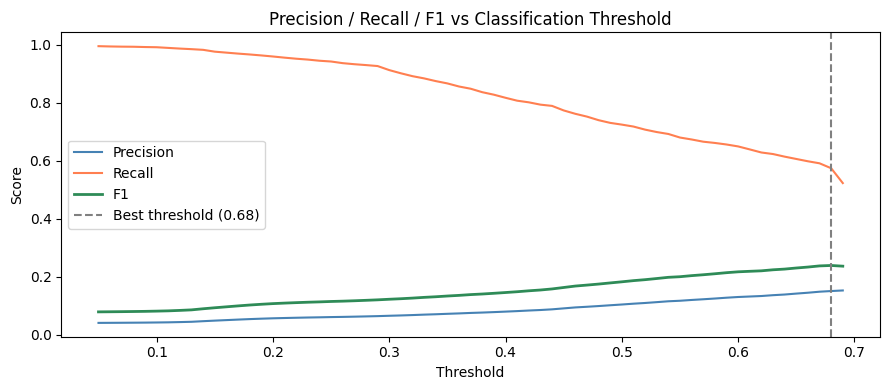

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", color="steelblue")
ax.plot(thresh_df["threshold"], thresh_df["recall"],    label="Recall",    color="coral")
ax.plot(thresh_df["threshold"], thresh_df["f1"],        label="F1",        color="seagreen", linewidth=2)

ax.axvline(best_thresh, color="gray", linestyle="--", label=f"Best threshold ({best_thresh})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Classification Threshold")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# ── Generate Kaggle submission ──────────────────────────────────────────────

# 1. Load test data (same path pattern as train)
test_df = pd.read_csv("/kaggle/input/datasets/bdc3013/featureengineering-clean/test_clean.csv")

test_ids = test_df["ID"]
X_test   = test_df.drop(columns=["ID"])   # drop ID; no TARGET column in test

# 2. Retrain the final model on ALL training data (no fold split)
scaler_final = StandardScaler()
X_train_sc   = scaler_final.fit_transform(X)          # X and y defined earlier in notebook

final_model  = LogisticRegression(
    C=best_C,              # best C found during grid search
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)
final_model.fit(X_train_sc, y)

# 3. Predict on test set
X_test_sc    = scaler_final.transform(X_test)
test_probs   = final_model.predict_proba(X_test_sc)[:, 1]
test_preds   = (test_probs >= best_thresh).astype(int)   # best_thresh from threshold sweep

# 4. Write submission CSV
submission = pd.DataFrame({"ID": test_ids, "TARGET": test_preds})
submission.to_csv("submission.csv", index=False)

print(f"Saved submission.csv  →  {submission.shape[0]} rows")
print(submission["TARGET"].value_counts())

Saved submission.csv  →  75818 rows
TARGET
0    64591
1    11227
Name: count, dtype: int64
